<a href="https://colab.research.google.com/github/Tanja000/Trading/blob/main/Kupfer_Chip_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

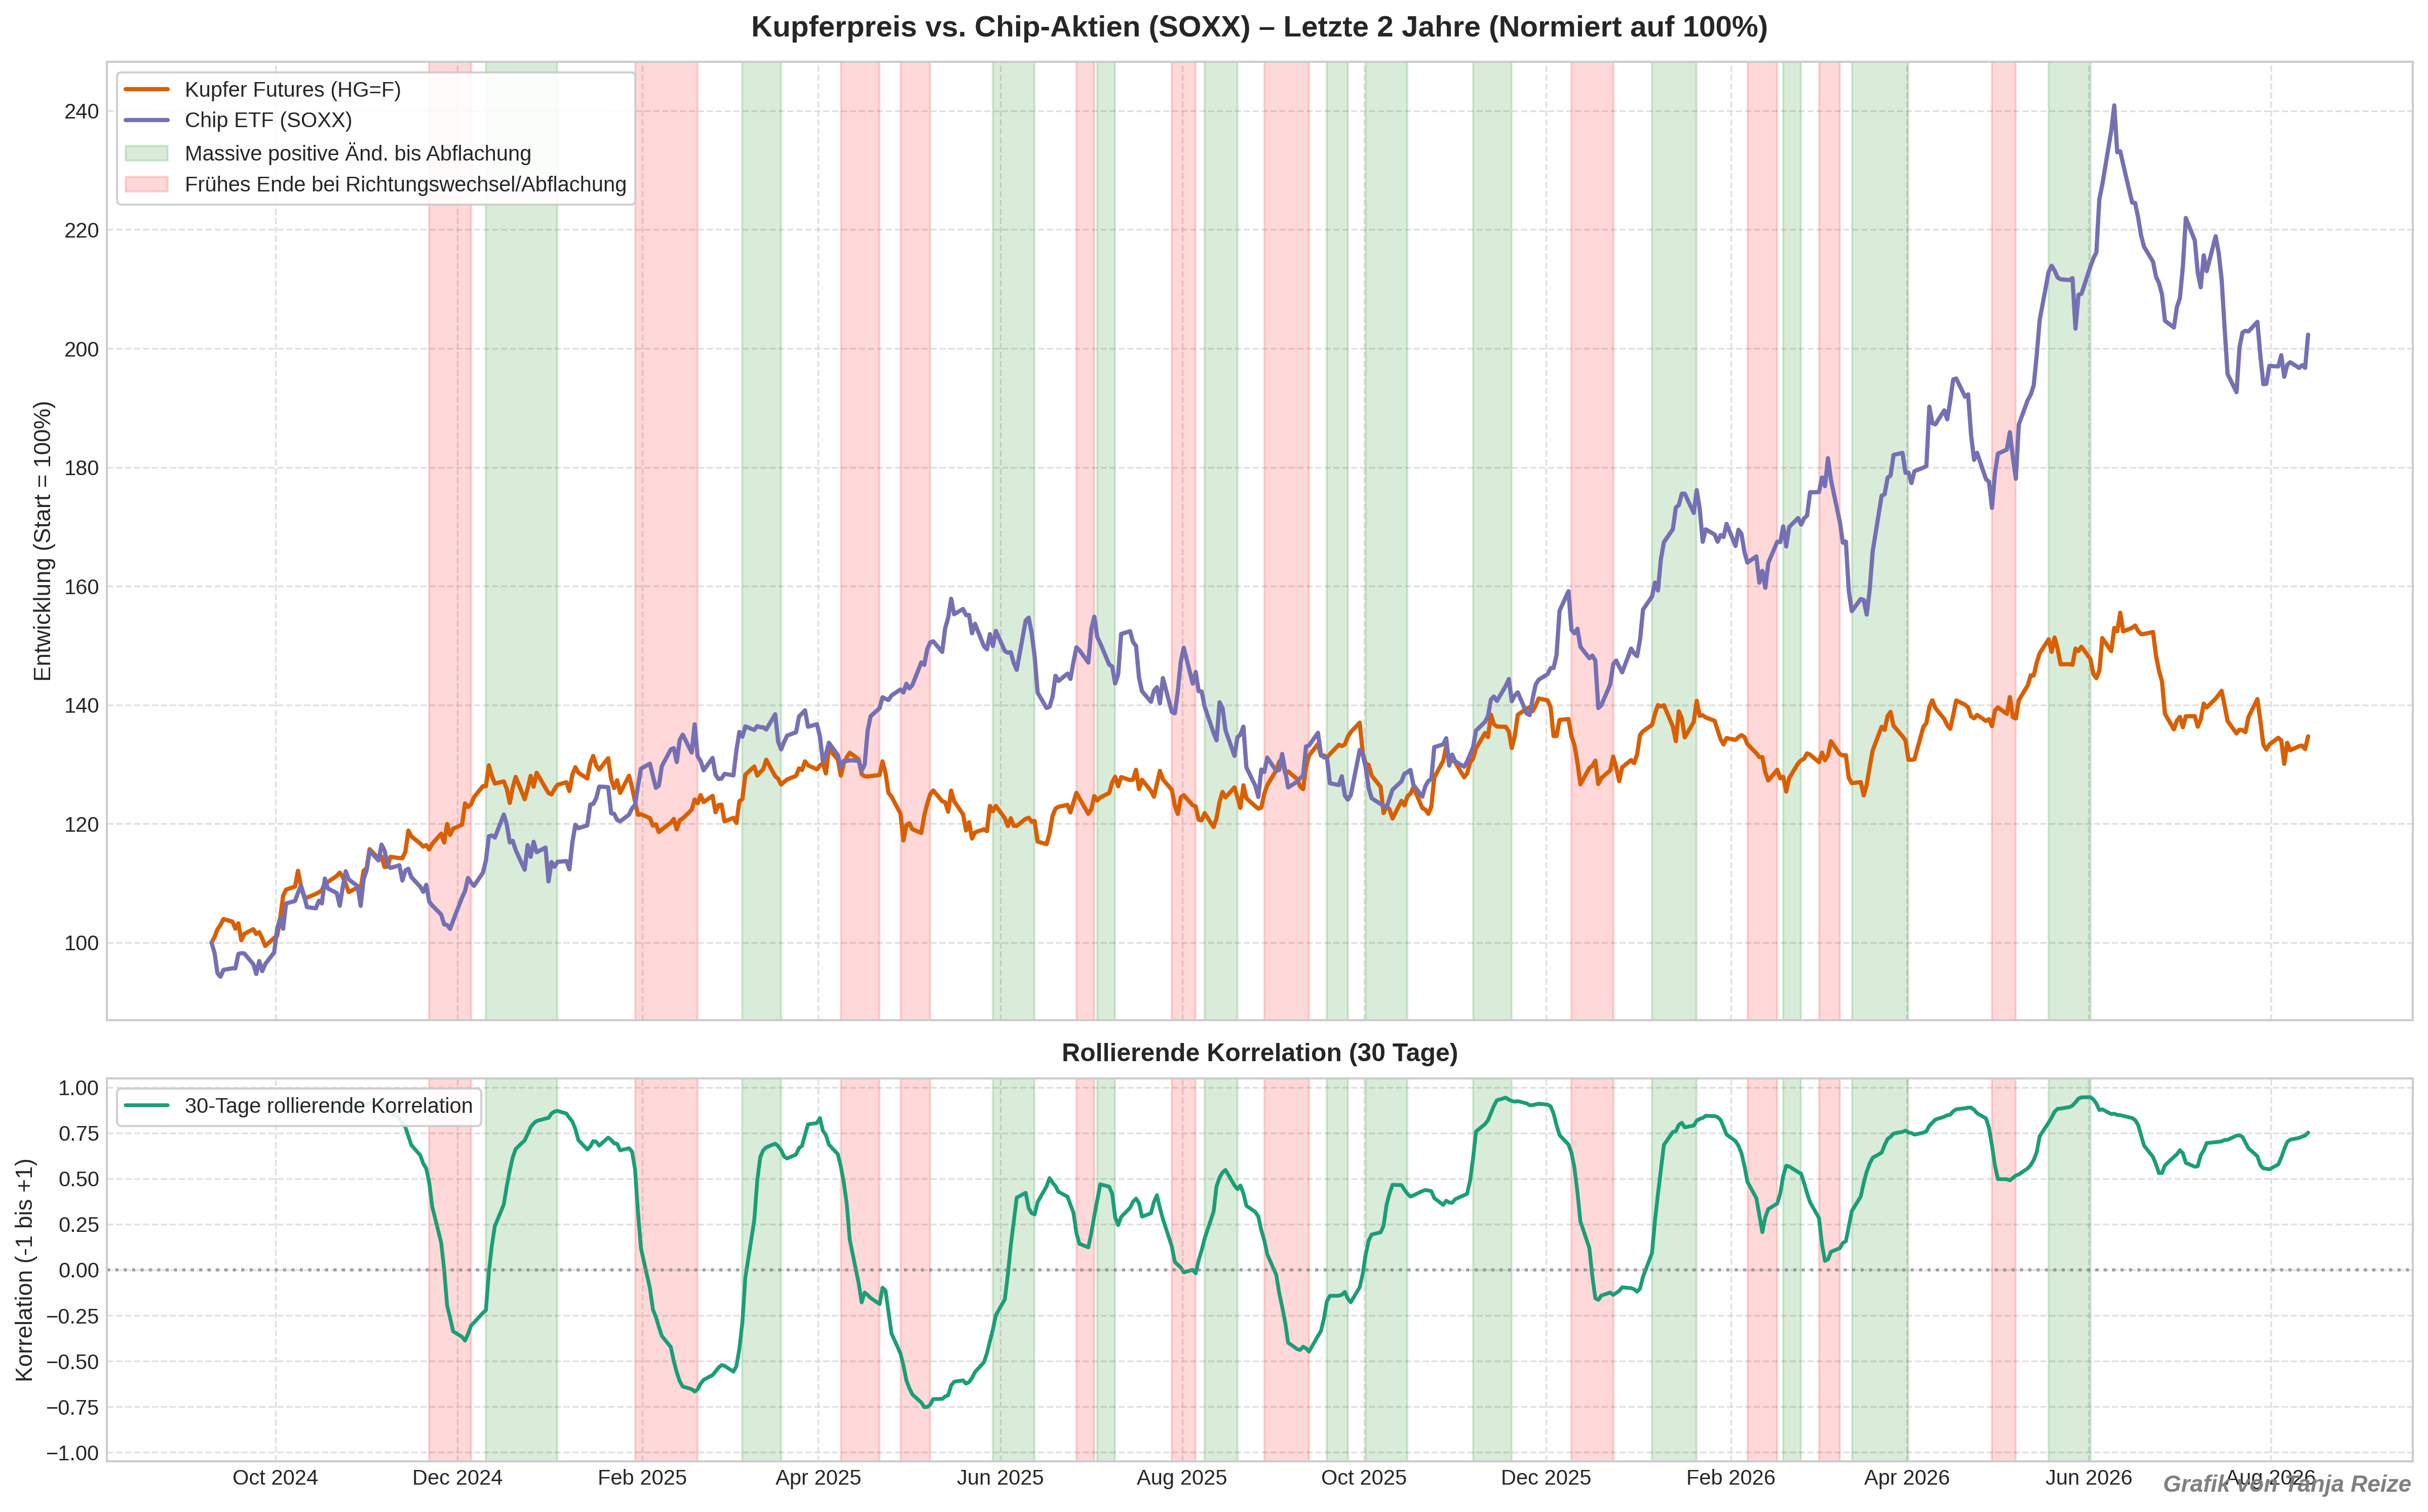

In [8]:
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set seed for reproducible synthetic data simulating 2 years
np.random.seed(101)
dates = pd.date_range(end=pd.Timestamp.now(), periods=504, freq='B')

returns_copper = np.random.normal(0.0003, 0.014, size=504)
returns_soxx = 0.6 * returns_copper + np.random.normal(0.0006, 0.017, size=504)

copper_prices = 100 * np.exp(np.cumsum(returns_copper))
soxx_prices = 100 * np.exp(np.cumsum(returns_soxx))

df = pd.DataFrame({'Kupfer (HG=F)': copper_prices, 'Chip ETF (SOXX)': soxx_prices}, index=dates)

norm_df = (df / df.iloc[0]) * 100

# 30-day rolling correlation
df['Correlation'] = df['Kupfer (HG=F)'].rolling(window=30).corr(df['Chip ETF (SOXX)'])

# Smooth correlation slightly to compute stable gradient
corr_smoothed = df['Correlation'].rolling(window=5, min_periods=1).mean()
df['Corr_Gradient'] = np.gradient(corr_smoothed)

# Identify onset of massive gradient change (threshold top/bottom 15%)
pos_start_thresh = df['Corr_Gradient'].quantile(0.85)
neg_start_thresh = df['Corr_Gradient'].quantile(0.15)

# Flattening thresholds:
# Green ends when positive gradient drops below quantile 0.60
pos_flatten_thresh = df['Corr_Gradient'].quantile(0.60)
# Red ends MUCH earlier: as soon as gradient starts recovering towards 0 (quantile 0.30) OR turns positive (>0)
neg_flatten_thresh = df['Corr_Gradient'].quantile(0.30)

def get_gradient_event_blocks(df, start_thresh, direction="positive"):
    blocks = []
    in_block = False
    start_date = None

    for date, grad in df['Corr_Gradient'].items():
        if pd.isna(grad):
            continue

        if direction == "positive":
            if grad >= start_thresh and not in_block:
                in_block = True
                start_date = date
            elif in_block and grad <= pos_flatten_thresh:
                in_block = False
                blocks.append((start_date, date))
        else:
            # Red block starts at massive negative gradient drop
            if grad <= start_thresh and not in_block:
                in_block = True
                start_date = date
            # Red block ends strictly early: as soon as negative gradient starts to flatten out / change direction (> neg_flatten_thresh or > 0)
            elif in_block and (grad >= neg_flatten_thresh or grad >= 0):
                in_block = False
                blocks.append((start_date, date))

    if in_block:
        blocks.append((start_date, df.index[-1]))

    return blocks

green_blocks = get_gradient_event_blocks(df, pos_start_thresh, direction="positive")
red_blocks = get_gradient_event_blocks(df, neg_start_thresh, direction="negative")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]}, dpi=300)

# Plot 1: Normalized Prices
ax1.plot(norm_df.index, norm_df['Kupfer (HG=F)'], label='Kupfer Futures (HG=F)', color='#d95f02', linewidth=2)
ax1.plot(norm_df.index, norm_df['Chip ETF (SOXX)'], label='Chip ETF (SOXX)', color='#7570b3', linewidth=2)
ax1.set_title('Kupferpreis vs. Chip-Aktien (SOXX) – Letzte 2 Jahre (Normiert auf 100%)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Entwicklung (Start = 100%)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Rolling Correlation
ax2.plot(df.index, df['Correlation'], label='30-Tage rollierende Korrelation', color='#1b9e77', linewidth=1.8)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.7)
ax2.set_title('Rollierende Korrelation (30 Tage)', fontsize=12, fontweight='bold', pad=8)
ax2.set_ylabel('Korrelation (-1 bis +1)', fontsize=11)
ax2.set_ylim(-1.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)

# Draw transparent spans
for idx, (start, end) in enumerate(green_blocks):
    lbl = 'Massive positive Änd. bis Abflachung' if idx == 0 else ""
    ax1.axvspan(start, end, color='green', alpha=0.15, label=lbl)
    ax2.axvspan(start, end, color='green', alpha=0.15)

for idx, (start, end) in enumerate(red_blocks):
    lbl = 'Frühes Ende bei Richtungswechsel/Abflachung' if idx == 0 else ""
    ax1.axvspan(start, end, color='red', alpha=0.15, label=lbl)
    ax2.axvspan(start, end, color='red', alpha=0.15)

ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax2.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# Watermark
fig.text(0.99, 0.01, 'Grafik von Tanja Reize', fontsize=11, color='gray',
         ha='right', va='bottom', fontstyle='italic', fontweight='bold')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()

# Save PNG
output_png = "kupfer_vs_chip_aktien_early_red_exit.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.show()